In [ ]:
!pip install tensorflow lime scikit-image matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d8177be8fb7b856235369f1a082e28fdeacb31a38d249a09daa7b376624febc8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Dense,Flatten,Dense
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [ ]:
#load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#reshape for CNN
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

#one-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# build CNN model
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])
#Train model
model.fit(x_train,y_train_cat,epochs=5,batch_size=64,validation_split=0.2)

#Evaluate
loss,accuracy = model.evaluate(x_test,y_test_cat)
print("Test Accuracy :",accuracy)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9437 - loss: 0.1925 - val_accuracy: 0.9783 - val_loss: 0.0786
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9809 - loss: 0.0636 - val_accuracy: 0.9820 - val_loss: 0.0623
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9871 - loss: 0.0418 - val_accuracy: 0.9793 - val_loss: 0.0677
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9907 - loss: 0.0293 - val_accuracy: 0.9843 - val_loss: 0.0595
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.9932 - loss: 0.0206 - val_accuracy: 0.9844 - val_loss: 0.0551
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9849 - loss: 0.0470
Test Accuracy : 0.9848999977111816


In [ ]:
from tensorflow import image
#LIME Explainability
# Convert grayscale to RGB
def to_rgb(img):
  return np.repeat(img, 3, axis=2)

#prediction function for LIME
def predict_fn(images):
  gray_images = np.array([img[:, :, 0] for img in images])
  gray_images = gray_images.reshape((-1, 28, 28, 1))
  return model.predict(gray_images)

# select sample images
index =0
image = x_test[index]

rgb_image = to_rgb(image)

# Create explainer
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    rgb_image.astype('double'),
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Generate explanation mask
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Actual Label: 7
Predicted Label: 7


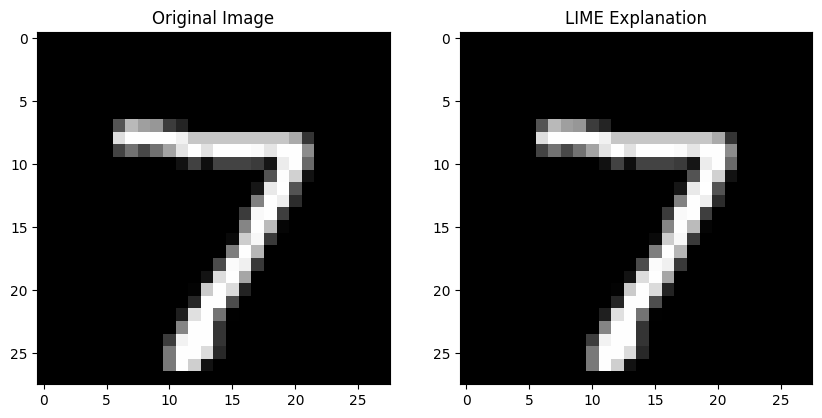

In [ ]:
# Step 4: Display Results
predicted = np.argmax(
    model.predict(image.reshape(1,28,28,1))
)

print("Actual Label:", y_test[index])
print("Predicted Label:", predicted)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image[:,:,0], cmap='gray')
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(mark_boundaries(temp,mask))
plt.title("LIME Explanation")

plt.show()